In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")

ЗАВДАННЯ 1. ПІДГОТОВКА НАБОРУ ДАНИХ

1.1 Вибір та завантаження набору даних


In [2]:
df = pd.read_csv("../data/GOOGL_stock_data.csv")

df.head()

,Date,Open,High,Low,Close,Volume,Daily_Return_Pct,Price_Range,Year,Month,Quarter,Day_of_Week
0,2004-08-19,2.4922,2.5846,2.3834,2.4837,893181924,-0.3411,0.2012,2004,8,3,Thursday
1,2004-08-20,2.6901,2.7093,2.4962,2.5088,456686856,-6.7395,0.2131,2004,8,3,Friday
2,2004-08-23,2.7172,2.8185,2.7085,2.7507,365122512,1.2329,0.1100,2004,8,3,Monday
3,2004-08-24,2.6047,2.7718,2.5724,2.7629,304946748,6.0736,0.1994,2004,8,3,Tuesday
4,2004-08-25,2.6328,2.6824,2.5801,2.6069,183772044,-0.9837,0.1023,2004,8,3,Wednesday


1.2 Базова підготовка даних

In [3]:
df.isna().sum()

Date                0
Open                0
High                0
Low                 0
Close               0
Volume              0
Daily_Return_Pct    0
Price_Range         0
Year                0
Month               0
Quarter             0
Day_of_Week         0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

In [6]:
df.dtypes

Date                datetime64[ns]
Open                       float64
High                       float64
Low                        float64
Close                      float64
Volume                       int64
Daily_Return_Pct           float64
Price_Range                float64
Year                         int64
Month                        int64
Quarter                      int64
Day_of_Week                 object
dtype: object

ЗАВДАННЯ 2. ВІЗУАЛЬНИЙ АНАЛІЗ ДАНИХ

2.1 Розподіл однієї змінної

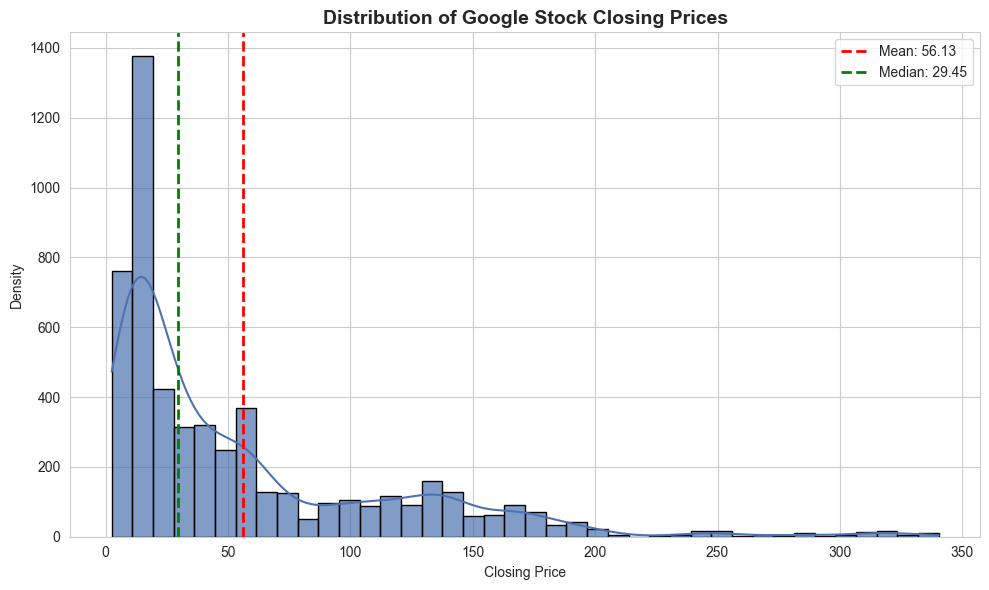

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Close"],
    bins=40,
    kde=True,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.7
)

plt.axvline(df["Close"].mean(), color="red", linestyle="--", linewidth=2,
            label=f"Mean: {df['Close'].mean():.2f}")

plt.axvline(df["Close"].median(), color="green", linestyle="--", linewidth=2,
            label=f"Median: {df['Close'].median():.2f}")

plt.title("Distribution of Google Stock Closing Prices", fontsize=14, fontweight="bold")
plt.xlabel("Closing Price")
plt.ylabel("Density")

plt.legend()
plt.tight_layout()
plt.show()

Висновок

Розподіл цін закриття є правосторонньо асиметричним. Основна частина значень зосереджена у середньому діапазоні, тоді як високі значення трапляються значно рідше.

2.2 Порівняння категорій

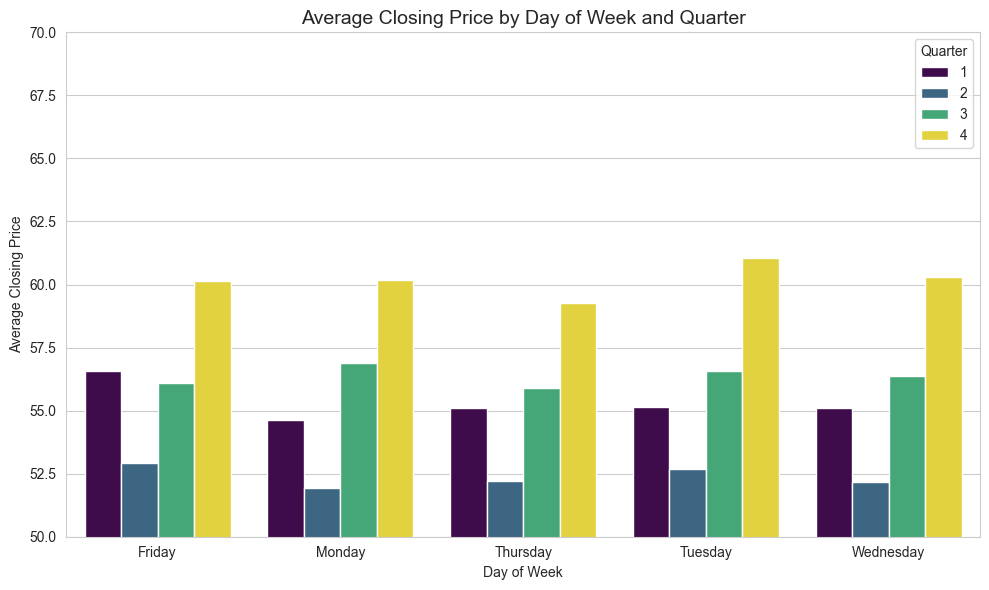

In [8]:
plt.figure(figsize=(10,6))

avg_close = df.groupby(["Day_of_Week","Quarter"])["Close"].mean().reset_index()

sns.barplot(
    data=avg_close,
    x="Day_of_Week",
    y="Close",
    hue="Quarter",
    palette="viridis"
)

plt.ylim(50, 70)
plt.title("Average Closing Price by Day of Week and Quarter", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Average Closing Price")

plt.legend(title="Quarter")
plt.tight_layout()
plt.show()

Висновок

Середня ціна акцій змінюється залежно від кварталу. Проте між днями тижня суттєвої різниці не спостерігається.

2.3 Аналіз розкиду та викидів

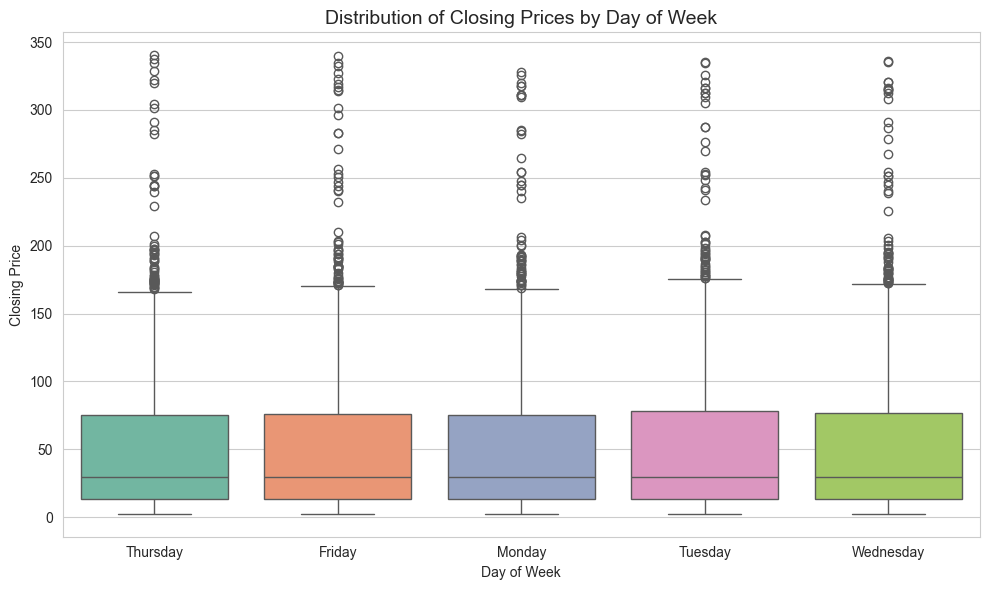

In [9]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Day_of_Week",
    y="Close",
    hue="Day_of_Week",
    palette="Set2",
    legend=False
)

plt.title("Distribution of Closing Prices by Day of Week", fontsize=14)
plt.xlabel("Day of Week")
plt.ylabel("Closing Price")

plt.tight_layout()
plt.show()

Висновок

Медіанні значення цін для різних днів тижня майже однакові. Водночас спостерігаються окремі викиди, що свідчить про періоди різких коливань ціни

2.4 Структура та пропорції

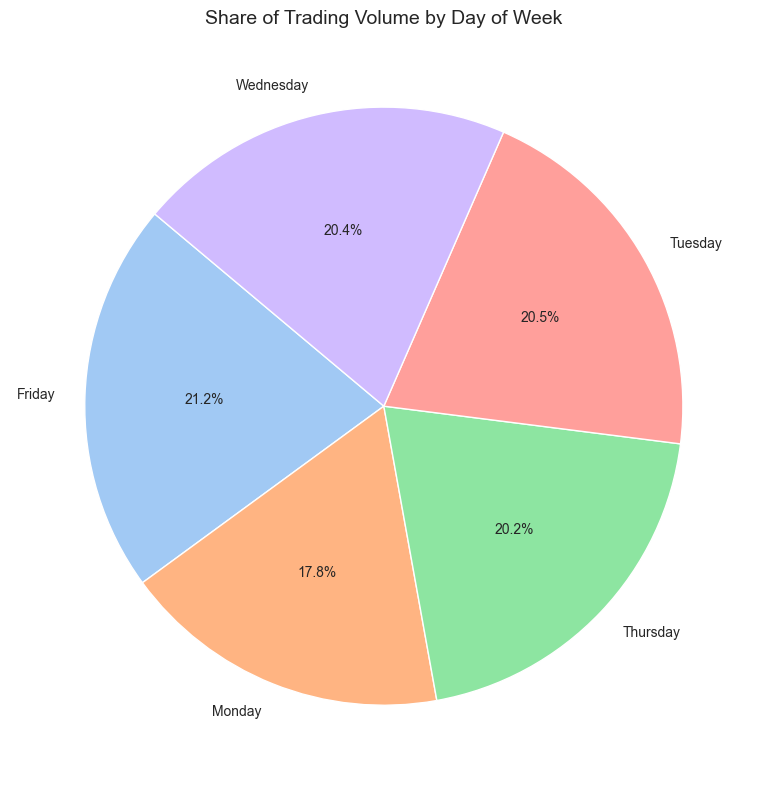

In [10]:
plt.figure(figsize=(8,8))

volume_share = df.groupby("Day_of_Week")["Volume"].sum()

colors = sns.color_palette("pastel")

plt.pie(
    volume_share,
    labels=volume_share.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140
)

plt.title("Share of Trading Volume by Day of Week", fontsize=14)

plt.tight_layout()
plt.show()

Висновок

Обсяг торгів розподілений між днями тижня досить рівномірно. Це означає, що торговельна активність не концентрується лише в один конкретний день.

2.5 Взаємозвʼязок двох числових змінних

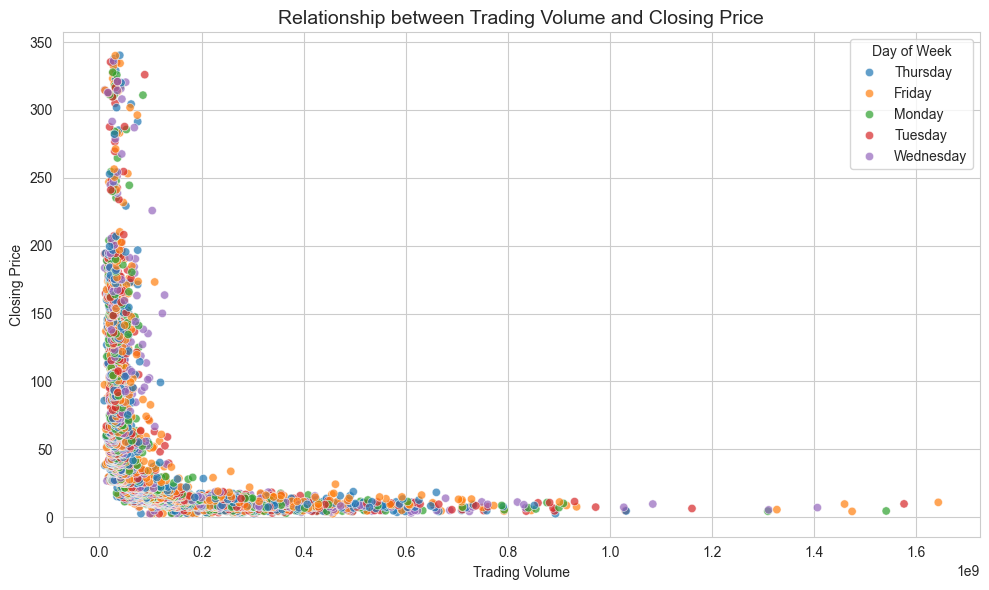

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Volume",
    y="Close",
    hue="Day_of_Week",
    palette="tab10",
    alpha=0.7
)

plt.title("Relationship between Trading Volume and Closing Price", fontsize=14)
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")

plt.legend(title="Day of Week")

plt.tight_layout()
plt.show()

Висновок

Візуалізація показує, що між обсягом торгів та ціною закриття немає чіткої лінійної залежності. Точки на графіку формують нелінійну структуру, схожу на гіперболічну криву.

2.6 Динаміка або тренд

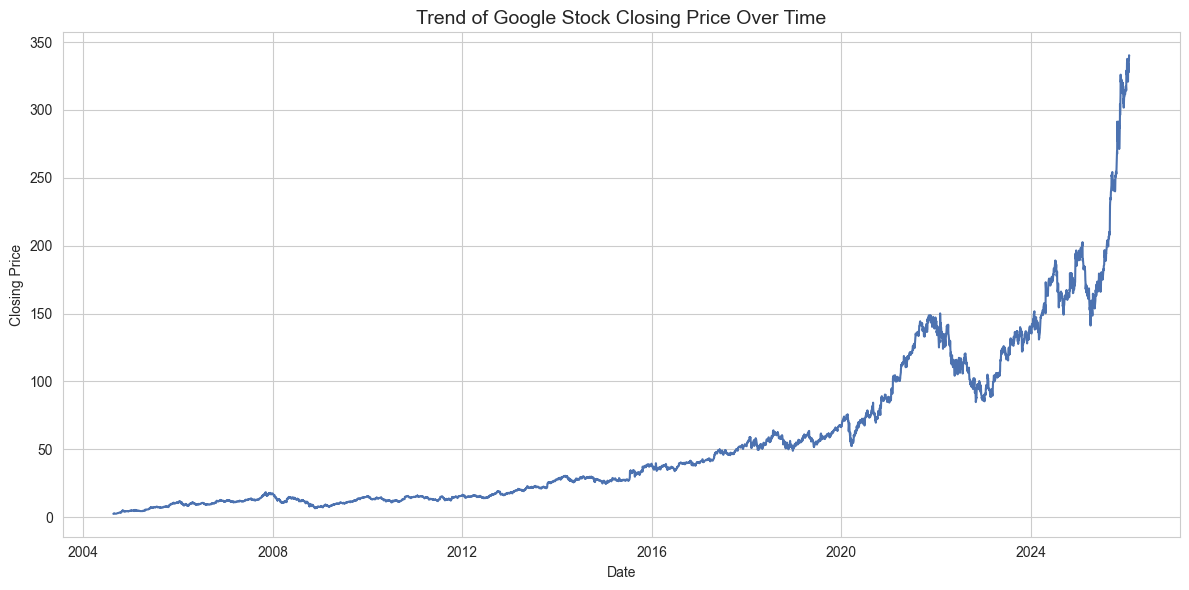

In [12]:
df_sorted = df.sort_values("Date")

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df_sorted,
    x="Date",
    y="Close",
    color="#4C72B0"
)

plt.title("Trend of Google Stock Closing Price Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.tight_layout()
plt.show()

Висновок

На графіку спостерігається довгострокова тенденція до зростання вартості акцій Google із періодичними короткостроковими коливаннями.

2.7 Матриця кореляцій

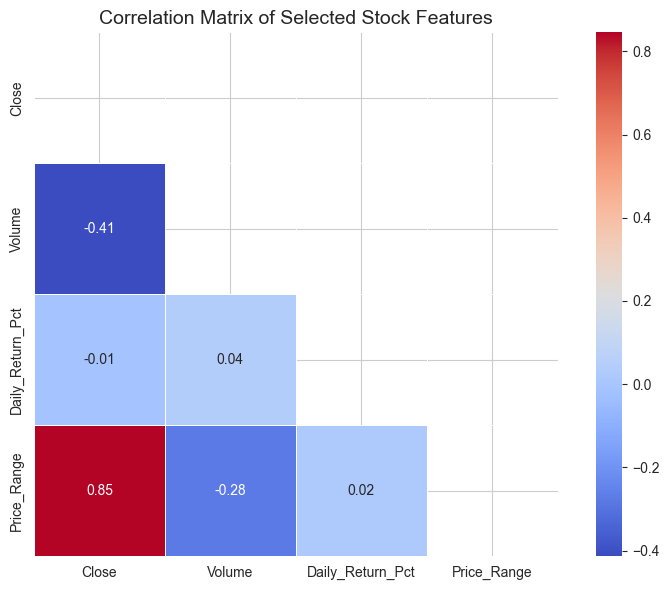

In [13]:
plt.figure(figsize=(8,6))

corr = df[[
    "Close",
    "Volume",
    "Daily_Return_Pct",
    "Price_Range"
]].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Selected Stock Features", fontsize=14)

plt.tight_layout()
plt.show()

Висновок

Найсильніший зв’язок спостерігається між Close та Price_Range, що означає: при вищій ціні закриття зазвичай більший денний діапазон ціни. Між Close та Volume є помірна негативна кореляція. Змінна Daily_Return_Pct майже не корелює з іншими показниками, тому явної лінійної залежності не спостерігається.

2.8 Комбінований графік

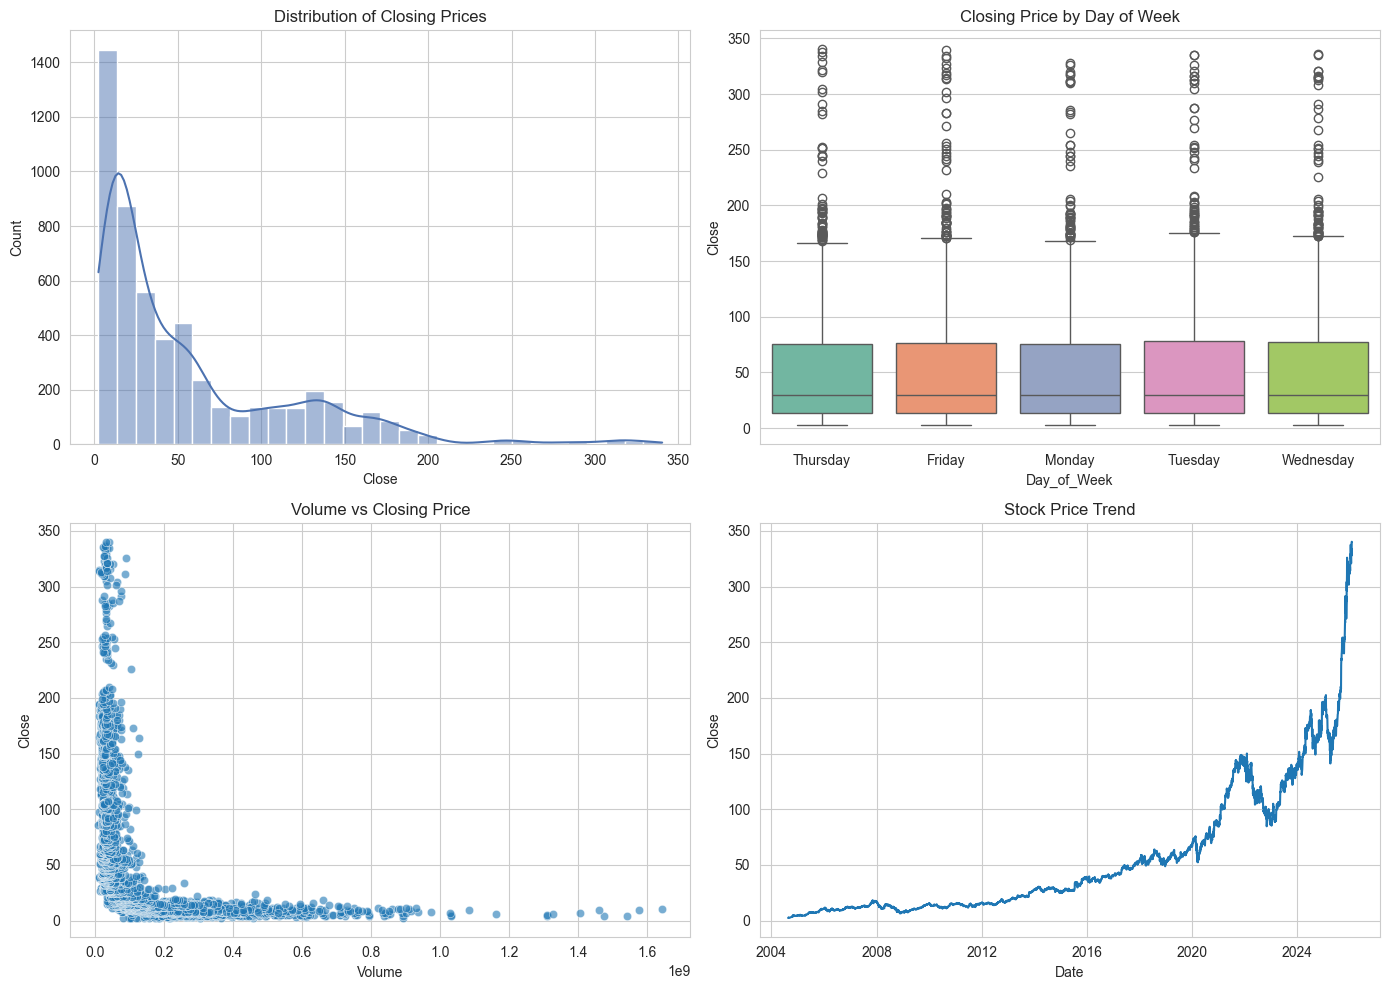

In [14]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.histplot(df["Close"], bins=30, kde=True, ax=axes[0,0], color="#4C72B0")
axes[0,0].set_title("Distribution of Closing Prices")

sns.boxplot(data=df, x="Day_of_Week", y="Close", ax=axes[0,1], palette="Set2", hue="Day_of_Week", legend=False)
axes[0,1].set_title("Closing Price by Day of Week")

sns.scatterplot(data=df, x="Volume", y="Close", ax=axes[1,0], alpha=0.6)
axes[1,0].set_title("Volume vs Closing Price")

df_sorted = df.sort_values("Date")
sns.lineplot(data=df_sorted, x="Date", y="Close", ax=axes[1,1])
axes[1,1].set_title("Stock Price Trend")

plt.tight_layout()
plt.show()

Висновок

Комбінована панель дозволяє одночасно побачити розподіл значень, варіації між групами, взаємозв’язок між показниками та довгострокову динаміку ціни акцій.